# Convolutional Neural Networks (CNN) — From Intuition to Practice

_Generated: 2025-11-12 18:20 UTC_

This Colab notebook builds intuition for CNNs and implements a compact image classifier on **CIFAR-10** using TensorFlow/Keras.
Along the way we visualize **filters** and **intermediate feature maps**, and compare a **baseline** vs **data augmentation**.

**Learning goals**
1. Understand local connectivity, weight sharing, and receptive fields.
2. Implement and train a small CNN on CIFAR-10.
3. Visualize learned filters and feature maps.
4. Improve generalization with data augmentation & regularization.


## 0. Environment & Utilities

In [1]:
# If running locally and TensorFlow is not installed, uncomment:
# !pip install -q tensorflow

import math, json, numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.19.0


## 1. Motivation, Intuition & Math

**Local connectivity & weight sharing.** A convolutional layer learns a small kernel $K$ and applies it across spatial locations.

This reduces parameters and builds **translation-equivariant** feature detectors.


**Cross-correlation vs convolution.** Deep learning libraries typically implement **cross-correlation**

$$ (I * K)(i,j) = \sum_m \sum_n I(i+m, j+n) K(m,n) $$

(without flipping $K$). The term “convolution layer” is used by convention.


**Output size (2D):** For input $H\times W$, kernel size $k$, padding $p$, stride $s$:

$$ H_{\text{out}} = \left\lfloor \frac{H + 2p - k}{s} \right\rfloor + 1, \quad W_{\text{out}} = \left\lfloor \frac{W + 2p - k}{s} \right\rfloor + 1. $$


**ReLU:** $\mathrm{ReLU}(x)=\max(0,x)$ introduces nonlinearity.


**Pooling:** Downsamples to gain invariance (e.g., max-pooling 2×2 halves spatial size).


**Backprop (intuition):** Filter gradients correlate input patches with upstream gradients.

Weight update: $K \leftarrow K - \eta\, \partial L/\partial K$.


## 2. CIFAR-10 Dataset

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train: (50000, 32, 32, 3) (50000, 10)
Test : (10000, 32, 32, 3) (10000, 10)


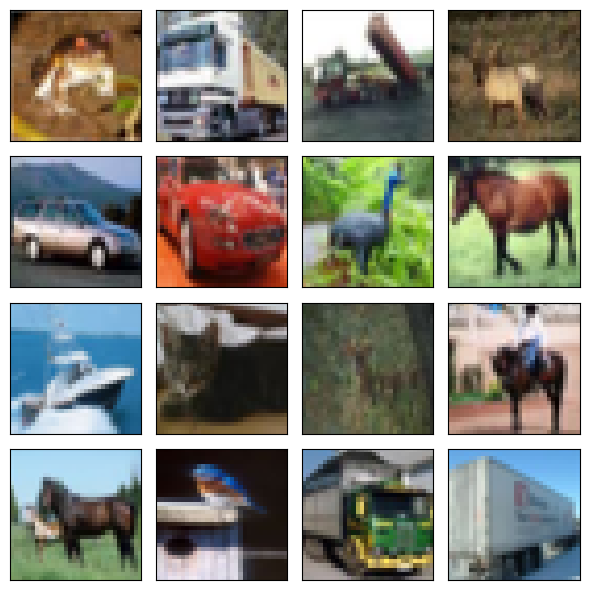

In [2]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
num_classes = 10

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

print('Train:', x_train.shape, y_train_cat.shape)
print('Test :', x_test.shape, y_test_cat.shape)

# Show a grid of sample images
fig = plt.figure(figsize=(6,6))
for i in range(16):
    ax = fig.add_subplot(4,4,i+1)
    ax.imshow(x_train[i])
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 3. Utility — Plot Training Curves

In [3]:
def plot_history(hist, title='Training history'):
    plt.figure()
    plt.plot(hist.history['loss'], label='loss')
    if 'val_loss' in hist.history:
        plt.plot(hist.history['val_loss'], label='val_loss')
    if 'accuracy' in hist.history:
        plt.plot(hist.history['accuracy'], label='accuracy')
    if 'val_accuracy' in hist.history:
        plt.plot(hist.history['val_accuracy'], label='val_accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Metric'); plt.title(title); plt.legend(); plt.show()

## 4. Baseline CNN Architecture
Two conv blocks + dense head. Kept small for quick training; increase filters/epochs for higher accuracy.

In [4]:
tf.keras.backend.clear_session()

def make_baseline(input_shape=(32,32,3), num_classes=10):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = make_baseline()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist_base = model.fit(
    x_train, y_train_cat,
    validation_split=0.1,
    epochs=10, batch_size=128, verbose=1
)
plot_history(hist_base, title='Baseline CNN: loss/accuracy')

Epoch 1/10
206/352 ━━━━━━━━━━━━━━━━━━━━ 1:33 643ms/step - accuracy: 0.2019 - loss: 2.1297

### 4.1 Evaluate & Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print('Test accuracy:', round(test_acc, 4))

y_pred = model.predict(x_test, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test.flatten(), y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, colorbar=False)
plt.title('Confusion Matrix (Baseline CNN)')
plt.show()

## 5. Visualize Learned Filters (First Conv Layer)

In [ ]:
first_conv = None
for layer in model.layers:
    if isinstance(layer, layers.Conv2D):
        first_conv = layer
        break

filters, biases = first_conv.get_weights()
print('Filter tensor shape:', filters.shape)  # (kH, kW, inC, outC)

# Normalize filters to 0..1 for display
f_min, f_max = filters.min(), filters.max()
filters_vis = (filters - f_min) / (f_max - f_min + 1e-8)

n_filters = min(filters_vis.shape[-1], 16)
fig = plt.figure(figsize=(8,2))
for i in range(n_filters):
    ax = fig.add_subplot(2,8,i+1)
    ax.imshow(filters_vis[:,: , :, i])
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('First Conv Layer Filters'); plt.tight_layout(); plt.show()

## 6. Visualize Intermediate Feature Maps

In [ ]:
# Build a model that outputs activations after the first conv block
layer_outputs = []
for lyr in model.layers:
    if isinstance(lyr, layers.Conv2D):
        layer_outputs.append(lyr.output)
        # stop after a couple of convs for speed
        if len(layer_outputs) == 2:
            break

act_model = tf.keras.Model(inputs=model.input, outputs=layer_outputs)

# Pick one test image
idx = 0
img = x_test[idx:idx+1]
activations = act_model.predict(img, verbose=0)

for li, act in enumerate(activations, start=1):
    n_maps = min(act.shape[-1], 8)
    fig = plt.figure(figsize=(8,2))
    for i in range(n_maps):
        ax = fig.add_subplot(2,4,i+1)
        ax.imshow(act[0,:,:,i], cmap='gray')
        ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle(f'Feature maps from Conv Layer {li}')
    plt.tight_layout(); plt.show()

## 7. Data Augmentation
Random flips and shifts can improve generalization. We train a second model using augmentation.

In [ ]:
augmenter = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomTranslation(0.1, 0.1),
])

def make_augmented(input_shape=(32,32,3), num_classes=10):
    inputs = layers.Input(shape=input_shape)
    x = augmenter(inputs)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

model_aug = make_augmented()
model_aug.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_aug.summary()

In [ ]:
hist_aug = model_aug.fit(
    x_train, y_train_cat,
    validation_split=0.1,
    epochs=10, batch_size=128, verbose=1
)
plot_history(hist_aug, title='Augmented CNN: loss/accuracy')

In [ ]:
test_loss_aug, test_acc_aug = model_aug.evaluate(x_test, y_test_cat, verbose=0)
print('Test accuracy (augmented):', round(test_acc_aug, 4))

## 8. Regularization & Practical Tips


- **Dropout** in conv blocks and dense layers to reduce co-adaptation.

- **L2 weight decay** (kernel_regularizer) for smoother filters and better generalization.

- **Batch size & learning rate** tuning can significantly affect convergence.

- **Early stopping** and **model checkpointing** to avoid overfitting.


## 9. (Bonus) Transfer Learning with MobileNetV2
We resize CIFAR-10 to 96×96 and fine-tune a lightweight ImageNet-pretrained backbone.
_This cell downloads pretrained weights from the internet when run in Colab._

In [ ]:
try:
    tf.keras.backend.clear_session()
    inputs = layers.Input(shape=(96,96,3))
    x = layers.Resizing(96,96)(inputs)
    base = tf.keras.applications.MobileNetV2(input_shape=(96,96,3), include_top=False, weights='imagenet')
    base.trainable = False
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    tl_model = models.Model(inputs, outputs)
    tl_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Resize training data on the fly for a quick demo
    def resize_batch(x):
        return tf.image.resize(x, (96,96)).numpy()
    x_train_96 = resize_batch(x_train[:20000])
    y_train_96 = y_train_cat[:20000]
    x_val_96   = resize_batch(x_train[20000:22000])
    y_val_96   = y_train_cat[20000:22000]

    hist_tl = tl_model.fit(x_train_96, y_train_96, validation_data=(x_val_96, y_val_96),
                           epochs=3, batch_size=128, verbose=1)
    plot_history(hist_tl, title='Transfer Learning (frozen backbone)')
except Exception as e:
    print('Transfer learning demo skipped:', e)

## 10. Save Trained Model (Optional)

In [ ]:
model.save('cnn_baseline.h5')
model_aug.save('cnn_augmented.h5')
print('Saved cnn_baseline.h5 and cnn_augmented.h5')